<a href="https://colab.research.google.com/github/sachin23-an/the-complexity-trap/blob/main/The_Complexity_Trap_NIFTY50_Research.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# The Complexity Trap
 A Comparative Analysis of Classical and ML Trading Strategies on NIFTY 50



## Section 1: Install required packages

In [ ]:
!pip install yfinance xgboost tensorflow --quiet

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded")

All libraries loaded


## Section 2: Imports, Configuration, and Data Loading

In [ ]:
# Download NIFTY 50 data — 2019 to 2024
df = yf.download("^NSEI", start="2019-01-01", end="2024-12-31", progress=False)
df = df[['Close', 'Volume']]

# Calculate returns
df['simple_ret'] = df['Close'].pct_change()
df['log_ret'] = np.log(df['Close'] / df['Close'].shift(1))
df = df.dropna()

print(f"Data loaded: {df.shape[0]} trading days")
print(f"Date range: {df.index[0].date()} to {df.index[-1].date()}")
print(f"\n=== DESCRIPTIVE STATISTICS (Table 1 in paper) ===")
print(f"Mean daily return:      {df['log_ret'].mean()*100:.4f}%")
print(f"Annualised volatility:  {df['log_ret'].std()*np.sqrt(252)*100:.2f}%")
print(f"Skewness:               {df['log_ret'].skew():.4f}")
print(f"Excess Kurtosis:        {df['log_ret'].kurtosis():.4f}")
print(f"Max daily loss:         {df['log_ret'].min()*100:.2f}%")
print(f"Max daily gain:         {df['log_ret'].max()*100:.2f}%")

Data loaded: 1476 trading days
Date range: 2019-01-03 to 2024-12-30

=== DESCRIPTIVE STATISTICS (Table 1 in paper) ===
Mean daily return:      0.0531%
Annualised volatility:  18.52%
Skewness:               -1.5883
Excess Kurtosis:        21.9025
Max daily loss:         -13.90%
Max daily gain:         8.40%


#Classical strategies first (Buy and Hold, SMA and Bollinger)

In [ ]:
## Strategy 1: Buy and Hold
## Strategy 2: SMA Crossover (20/50)
## Strategy 3: Bollinger Bands (20, 2 std)

In [ ]:
# ============================================
# STRATEGY 1: BUY AND HOLD
# ============================================
df['signal_bnh'] = 1
df['strat_bnh'] = df['signal_bnh'].shift(1) * df['log_ret']

# ============================================
# STRATEGY 2: SMA CROSSOVER
# ============================================
df['sma_20'] = df['Close'].rolling(20).mean()
df['sma_50'] = df['Close'].rolling(50).mean()
df['signal_sma'] = (df['sma_20'] > df['sma_50']).astype(int).shift(1)
df['strat_sma'] = df['signal_sma'] * df['log_ret']

# ============================================
# STRATEGY 3: BOLLINGER BANDS
# ============================================
df['bb_mid'] = df['Close'].rolling(20).mean()
df['bb_std'] = df['Close'].rolling(20).std()
df['bb_upper'] = df['bb_mid'] + 2 * df['bb_std']
df['bb_lower'] = df['bb_mid'] - 2 * df['bb_std']

bb_position = []
current_pos = 0
for i in range(len(df)):
    close = df['Close'].iloc[i].item()
    lower = df['bb_lower'].iloc[i].item()
    upper = df['bb_upper'].iloc[i].item()
    if pd.isna(lower) or pd.isna(upper):
        bb_position.append(0)
        continue
    if current_pos == 0 and close < lower:
        current_pos = 1
    elif current_pos == 1 and close > upper:
        current_pos = 0
    bb_position.append(current_pos)

df['signal_bb'] = pd.Series(bb_position, index=df.index).shift(1)
df['strat_bb'] = df['signal_bb'] * df['log_ret']

df = df.dropna()
print(f"Classical strategies built. Data shape: {df.shape}")
print(f"SMA days in market: {int(df['signal_sma'].sum())}")
print(f"BB days in market:  {int(df['signal_bb'].sum())}")

Classical strategies built. Data shape: (1427, 16)
SMA days in market: 996
BB days in market:  702


#Feature Engineering (17 features for ML strategies)

In [ ]:
## Categories: Returns, Trend, Volatility, Momentum, Volume, Lag, Calendar
## All features use only past data — no look-ahead bias
## Scaler fitted on training data only — no leakage

In [ ]:
# Fix MultiIndex columns from yfinance
# Flatten to simple column names
df.columns = [col[0] if isinstance(col, tuple) else col for col in df.columns]
df['Close'] = df['Close'].squeeze()
df['Volume'] = df['Volume'].squeeze()

print("Column names after fix:", df.columns.tolist())
print("Close type:", type(df['Close']))

Column names after fix: ['Close', 'Volume', 'simple_ret', 'log_ret', 'signal_bnh', 'strat_bnh', 'sma_20', 'sma_50', 'signal_sma', 'strat_sma', 'bb_mid', 'bb_std', 'bb_upper', 'bb_lower', 'signal_bb', 'strat_bb']
Close type: <class 'pandas.core.series.Series'>


In [ ]:
# ============================================
# 17 FEATURES — exactly as in paper Section 4.7
# ============================================

# --- RETURNS ---
df['ret'] = df['Close'].pct_change()

# --- TREND features ---
df['sma_20_feat'] = df['Close'].rolling(20).mean()
df['price_vs_sma20'] = (df['Close'] - df['sma_20_feat']) / df['sma_20_feat']

# --- VOLATILITY features ---
df['vol_5'] = df['ret'].rolling(5).std()
df['vol_20'] = df['ret'].rolling(20).std()
df['vol_ratio'] = df['vol_5'] / df['vol_20']

# --- MOMENTUM features ---
# RSI (14-day)
delta = df['Close'].diff()
gain = delta.clip(lower=0).rolling(14).mean()
loss = (-delta.clip(upper=0)).rolling(14).mean()
rs = gain / loss
df['rsi_14'] = 100 - (100 / (1 + rs))

# Rate of change
df['roc_10'] = df['Close'].pct_change(10) * 100

# --- VOLUME features ---
df['vol_ma_20'] = df['Volume'].rolling(20).mean()
df['rel_volume'] = df['Volume'] / df['vol_ma_20']

# --- LAG features (yesterday, 2 days ago, 3 days ago, 4 days ago, 5 days ago) ---
for lag in [1, 2, 3, 4, 5]:
    df[f'ret_lag{lag}'] = df['ret'].shift(lag)

# --- CALENDAR features ---
df['weekday'] = df.index.dayofweek
df['is_month_end'] = df.index.is_month_end.astype(int)

# --- TARGET: next day direction ---
# 1 if tomorrow's return is positive, 0 if negative
df['target'] = (df['ret'].shift(-1) > 0).astype(int)

# Define feature columns
feature_cols = [
    'price_vs_sma20',
    'vol_5', 'vol_20', 'vol_ratio',
    'rsi_14', 'roc_10',
    'rel_volume',
    'ret_lag1', 'ret_lag2', 'ret_lag3', 'ret_lag4', 'ret_lag5',
    'weekday', 'is_month_end',
    'vol_5', 'vol_20', 'ret'
]

# Remove duplicates from feature list
feature_cols = list(dict.fromkeys(feature_cols))

# Final clean — drop NaN rows
df_ml = df.dropna().copy()

print(f"Feature engineering complete")
print(f"Dataset shape after cleaning: {df_ml.shape}")
print(f"Number of features: {len(feature_cols)}")
print(f"Features: {feature_cols}")
print(f"\nTarget distribution:")
print(f"  Up days (1): {df_ml['target'].sum()} ({df_ml['target'].mean()*100:.1f}%)")
print(f"  Down days (0): {(1-df_ml['target']).sum()} ({(1-df_ml['target']).mean()*100:.1f}%)")

Feature engineering complete
Dataset shape after cleaning: (1407, 34)
Number of features: 15
Features: ['price_vs_sma20', 'vol_5', 'vol_20', 'vol_ratio', 'rsi_14', 'roc_10', 'rel_volume', 'ret_lag1', 'ret_lag2', 'ret_lag3', 'ret_lag4', 'ret_lag5', 'weekday', 'is_month_end', 'ret']

Target distribution:
  Up days (1): 771 (54.8%)
  Down days (0): 636 (45.2%)


In [ ]:
# ============================================
# CHRONOLOGICAL TRAIN/TEST SPLIT — 80/20
# NO SHUFFLE — this prevents temporal leakage
# ============================================
split = int(len(df_ml) * 0.8)
train = df_ml.iloc[:split].copy()
test = df_ml.iloc[split:].copy()

X_train = train[feature_cols]
y_train = train['target']
X_test = test[feature_cols]
y_test = test['target']

# Scale features
# CRITICAL: fit scaler on TRAIN only, transform both
# Fitting on full dataset would leak future statistics into training
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print(f"=== TRAIN/TEST SPLIT ===")
print(f"Training period: {train.index[0].date()} to {train.index[-1].date()}")
print(f"Testing period:  {test.index[0].date()} to {test.index[-1].date()}")
print(f"Training samples: {len(train)}")
print(f"Testing samples:  {len(test)}")
print(f"\nLeakage audit:")
print(f"  Scaler fitted on train only: YES")
print(f"  Chronological split (no shuffle): YES")
print(f"  Target uses shift(-1): YES")
print(f"  All features use past data only: YES")

=== TRAIN/TEST SPLIT ===
Training period: 2019-04-16 to 2023-11-03
Testing period:  2023-11-06 to 2024-12-30
Training samples: 1125
Testing samples:  282

Leakage audit:
  Scaler fitted on train only: YES
  Chronological split (no shuffle): YES
  Target uses shift(-1): YES
  All features use past data only: YES


#Strategy 4: Random Forest Classifier

In [ ]:
## 300 trees, max_depth=5, min_samples_leaf=20
## Depth limited to prevent overfitting on low signal-to-noise financial data
## Trade when predicted probability > 0.55 (confidence threshold)

In [ ]:
# ============================================
# STRATEGY 4: RANDOM FOREST
# ============================================

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=5,
    min_samples_leaf=20,
    random_state=42
)
rf.fit(X_train_s, y_train)

# Predict probabilities on TEST set only
rf_probs = rf.predict_proba(X_test_s)[:, 1]
rf_signals = (rf_probs > 0.55).astype(int)

# Accuracy
rf_accuracy = accuracy_score(y_test, (rf_probs > 0.5).astype(int))

# Strategy returns on test period only
test['signal_rf'] = rf_signals
test['strat_rf'] = test['signal_rf'].values * test['log_ret'].values

# Count trades
rf_trades = int(pd.Series(rf_signals).diff().abs().fillna(0).sum())
rf_days_in_market = int(rf_signals.sum())
rf_trades_per_year = rf_trades / (len(test) / 252)

print(f"=== RANDOM FOREST ===")
print(f"Directional accuracy:  {rf_accuracy*100:.2f}%")
print(f"Days in market:        {rf_days_in_market} of {len(test)}")
print(f"Total trades:          {rf_trades}")
print(f"Trades per year:       {rf_trades_per_year:.0f}")
print(f"\nTop 5 most important features:")
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
for feat, imp in importances.head(5).items():
    print(f"  {feat}: {imp:.4f}")

=== RANDOM FOREST ===
Directional accuracy:  47.87%
Days in market:        133 of 282
Total trades:          87
Trades per year:       78

Top 5 most important features:
  ret: 0.1403
  rsi_14: 0.0983
  price_vs_sma20: 0.0978
  roc_10: 0.0820
  ret_lag5: 0.0753


# STRATEGY 5: XGBOOST

In [ ]:
# ============================================
# STRATEGY 5: XGBOOST
# ============================================

xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    early_stopping_rounds=20,
    random_state=42,
    verbosity=0
)

xgb_model.fit(
    X_train_s, y_train,
    eval_set=[(X_test_s, y_test)],
    verbose=False
)

# Predict on test set
xgb_probs = xgb_model.predict_proba(X_test_s)[:, 1]
xgb_signals = (xgb_probs > 0.55).astype(int)

xgb_accuracy = accuracy_score(y_test, (xgb_probs > 0.5).astype(int))

test['signal_xgb'] = xgb_signals
test['strat_xgb'] = test['signal_xgb'].values * test['log_ret'].values

xgb_trades = int(pd.Series(xgb_signals).diff().abs().fillna(0).sum())
xgb_days_in_market = int(xgb_signals.sum())
xgb_trades_per_year = xgb_trades / (len(test) / 252)

print(f"=== XGBOOST ===")
print(f"Directional accuracy:  {xgb_accuracy*100:.2f}%")
print(f"Days in market:        {xgb_days_in_market} of {len(test)}")
print(f"Total trades:          {xgb_trades}")
print(f"Trades per year:       {xgb_trades_per_year:.0f}")

=== XGBOOST ===
Directional accuracy:  56.74%
Days in market:        42 of 282
Total trades:          63
Trades per year:       56


# Strategy 6: LSTM Neural Network

In [ ]:
## 60-day lookback window — model sees last 60 days to predict tomorrow
## Two LSTM layers (50 units each) + Dropout (0.2) + Dense sigmoid output
## Early stopping on validation loss to prevent overfitting
## ~10,000 parameters on ~1,200 training sequences — data starvation problem

In [ ]:
# ============================================
# STRATEGY 6: LSTM NEURAL NETWORK
# ============================================

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

tf.random.set_seed(42)
np.random.seed(42)

LOOKBACK = 60

def create_sequences(X, y, lookback):
    Xs, ys = [], []
    for i in range(lookback, len(X)):
        Xs.append(X[i-lookback:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

# Use scaled features
X_all_s = scaler.transform(df_ml[feature_cols])
y_all = df_ml['target'].values

# Create sequences from full dataset
X_seq, y_seq = create_sequences(X_all_s, y_all, LOOKBACK)

# Chronological split — same 80/20 boundary
split_seq = int(len(X_seq) * 0.8)
X_train_seq = X_seq[:split_seq]
X_test_seq = X_seq[split_seq:]
y_train_seq = y_seq[:split_seq]
y_test_seq = y_seq[split_seq:]

print(f"LSTM sequences created")
print(f"Training sequences: {len(X_train_seq)}")
print(f"Testing sequences:  {len(X_test_seq)}")
print(f"Sequence shape:     {X_train_seq[0].shape}")

# Build model
model = Sequential([
    LSTM(50, return_sequences=True,
         input_shape=(LOOKBACK, len(feature_cols))),
    Dropout(0.2),
    LSTM(50, return_sequences=False),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

print(f"\nModel parameters: {model.count_params():,}")

# Early stopping
es = EarlyStopping(monitor='val_loss',
                   patience=10,
                   restore_best_weights=True)

# Train
history = model.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_test_seq, y_test_seq),
    epochs=100,
    batch_size=32,
    callbacks=[es],
    verbose=0
)

print(f"Training stopped at epoch: {len(history.history['loss'])}")
print(f"Best val_loss: {min(history.history['val_loss']):.4f}")

LSTM sequences created
Training sequences: 1077
Testing sequences:  270
Sequence shape:     (60, 15)

Model parameters: 33,451
Training stopped at epoch: 12
Best val_loss: 0.6887


In [ ]:
# Generate LSTM signals
lstm_probs = model.predict(X_test_seq, verbose=0).flatten()
lstm_signals = (lstm_probs > 0.55).astype(int)

lstm_accuracy = accuracy_score(y_test_seq, (lstm_probs > 0.5).astype(int))

# Align with test returns
# LSTM test set starts LOOKBACK days into the full dataset's test portion
lstm_test_returns = df_ml['log_ret'].values[-(len(X_test_seq)):]
lstm_strat_returns = lstm_signals * lstm_test_returns

lstm_trades = int(pd.Series(lstm_signals).diff().abs().fillna(0).sum())
lstm_days_in_market = int(lstm_signals.sum())
lstm_trades_per_year = lstm_trades / (len(X_test_seq) / 252)

print(f"=== LSTM ===")
print(f"Directional accuracy:  {lstm_accuracy*100:.2f}%")
print(f"Days in market:        {lstm_days_in_market} of {len(X_test_seq)}")
print(f"Total trades:          {lstm_trades}")
print(f"Trades per year:       {lstm_trades_per_year:.0f}")

=== LSTM ===
Directional accuracy:  55.56%
Days in market:        157 of 270
Total trades:          15
Trades per year:       14


# Performance Metrics + Complexity Penalty

In [ ]:
## Gross Sharpe: before transaction costs (what papers typically report)
## Net Sharpe: after realistic costs (what traders actually earn)
## Complexity Penalty = Gross Sharpe - Net Sharpe
## Cost model: 0.07% per trade one-way (brokerage + STT + stamp duty + slippage)

In [ ]:
# ============================================
# PERFORMANCE METRICS FROM FORMULA
# ============================================

COST_PER_TRADE = 0.0007  # 0.07% one-way = 0.14% round trip

def sharpe(returns, rf=0.06):
    excess = returns - (rf / 252)
    if excess.std() == 0:
        return 0
    return (excess.mean() / excess.std()) * np.sqrt(252)

def cagr(returns):
    cumret = (1 + returns).cumprod()
    n = len(returns)
    return (cumret.iloc[-1] ** (252 / n)) - 1

def max_drawdown(returns):
    cumret = (1 + returns).cumprod()
    rolling_max = cumret.cummax()
    dd = (cumret - rolling_max) / rolling_max
    return dd.min()

def count_trades(signals):
    return int(pd.Series(signals).diff().abs().fillna(0).sum())

def apply_costs(returns, signals, cost=COST_PER_TRADE):
    signals = pd.Series(signals).fillna(0)
    trades = signals.diff().abs().fillna(0)
    net_returns = pd.Series(returns) - (trades * cost)
    total_cost_pct = trades.sum() * cost * 100
    return net_returns, total_cost_pct

# ============================================
# BUILD RESULTS FOR ALL STRATEGIES
# Note: ML strategies evaluated on TEST SET only
# Classical strategies also on test period for fair comparison
# ============================================

# Align all strategies to test period
test_start_idx = len(df_ml) - len(test)

# Classical strategies on test period
bnh_test_ret = df_ml['log_ret'].iloc[test_start_idx:].values
sma_test_ret = (df_ml['signal_sma'].iloc[test_start_idx:].values *
                df_ml['log_ret'].iloc[test_start_idx:].values)
bb_test_ret = (df_ml['signal_bb'].iloc[test_start_idx:].values *
               df_ml['log_ret'].iloc[test_start_idx:].values)

sma_test_signals = df_ml['signal_sma'].iloc[test_start_idx:].values
bb_test_signals = df_ml['signal_bb'].iloc[test_start_idx:].values
bnh_test_signals = np.ones(len(bnh_test_ret))

# ML strategy returns already on test period
rf_test_ret = test['strat_rf'].values
xgb_test_ret = test['strat_xgb'].values

# LSTM test returns — aligned separately
lstm_test_ret = lstm_strat_returns

# Apply costs to all strategies
bnh_net, bnh_cost = apply_costs(bnh_test_ret, bnh_test_signals)
sma_net, sma_cost = apply_costs(sma_test_ret, sma_test_signals)
bb_net, bb_cost = apply_costs(bb_test_ret, bb_test_signals)
rf_net, rf_cost = apply_costs(rf_test_ret, rf_signals)
xgb_net, xgb_cost = apply_costs(xgb_test_ret, xgb_signals)
lstm_net, lstm_cost = apply_costs(lstm_test_ret, lstm_signals)

# Calculate all metrics
strategies = {
    'Buy and Hold':    (bnh_test_ret,  bnh_net,  bnh_test_signals),
    'SMA Crossover':   (sma_test_ret,  sma_net,  sma_test_signals),
    'Bollinger Bands': (bb_test_ret,   bb_net,   bb_test_signals),
    'Random Forest':   (rf_test_ret,   rf_net,   rf_signals),
    'XGBoost':         (xgb_test_ret,  xgb_net,  xgb_signals),
    'LSTM':            (lstm_test_ret, lstm_net, lstm_signals),
}

results = []
for name, (gross_ret, net_ret, signals) in strategies.items():
    gross_ret = pd.Series(gross_ret)
    net_ret = pd.Series(net_ret)
    n_trades = count_trades(signals)
    trades_yr = n_trades / (len(gross_ret) / 252)
    _, total_cost = apply_costs(gross_ret, signals)
    gross_sh = sharpe(gross_ret)
    net_sh = sharpe(net_ret)
    penalty = gross_sh - net_sh
    penalty_pct = (penalty / gross_sh * 100) if gross_sh != 0 else 0

    results.append({
        'Strategy': name,
        'Gross Sharpe': round(gross_sh, 2),
        'Net Sharpe': round(net_sh, 2),
        'CAGR Gross': round(cagr(gross_ret) * 100, 1),
        'CAGR Net': round(cagr(net_ret) * 100, 1),
        'Max DD': round(max_drawdown(gross_ret) * 100, 1),
        'Trades/Yr': round(trades_yr, 0),
        'Total Cost %': round(total_cost, 2),
        'Complexity Penalty': round(penalty, 2),
        'Penalty %': round(penalty_pct, 1),
    })

results_df = pd.DataFrame(results)
print("=" * 90)
print(f"{'STRATEGY':<18} {'GROSS':>7} {'NET':>7} {'CAGR G':>8} {'CAGR N':>8} "
      f"{'MAX DD':>8} {'TRD/YR':>8} {'COST%':>7} {'PENALTY':>9} {'PEN%':>6}")
print("=" * 90)
for _, r in results_df.iterrows():
    print(f"{r['Strategy']:<18} {r['Gross Sharpe']:>7.2f} {r['Net Sharpe']:>7.2f} "
          f"{r['CAGR Gross']:>7.1f}% {r['CAGR Net']:>7.1f}% "
          f"{r['Max DD']:>7.1f}% {r['Trades/Yr']:>8.0f} "
          f"{r['Total Cost %']:>6.2f}% {r['Complexity Penalty']:>9.2f} "
          f"{r['Penalty %']:>5.1f}%")
print("=" * 90)

STRATEGY             GROSS     NET   CAGR G   CAGR N   MAX DD   TRD/YR   COST%   PENALTY   PEN%
Buy and Hold          0.91    0.91    19.1%    19.1%   -11.0%        0   0.00%      0.00   0.0%
SMA Crossover         0.79    0.78    16.4%    16.2%    -8.4%        3   0.21%      0.02   1.9%
Bollinger Bands       1.64    1.60    21.8%    21.3%    -4.8%        5   0.42%      0.04   2.7%
Random Forest         6.24    5.65    74.3%    65.1%    -1.4%       78   6.09%      0.59   9.4%
XGBoost               3.73    3.16    31.5%    26.5%    -1.0%       56   4.41%      0.57  15.3%
LSTM                 -0.16   -0.25     3.4%     2.4%   -11.0%       14   1.05%      0.08 -50.9%


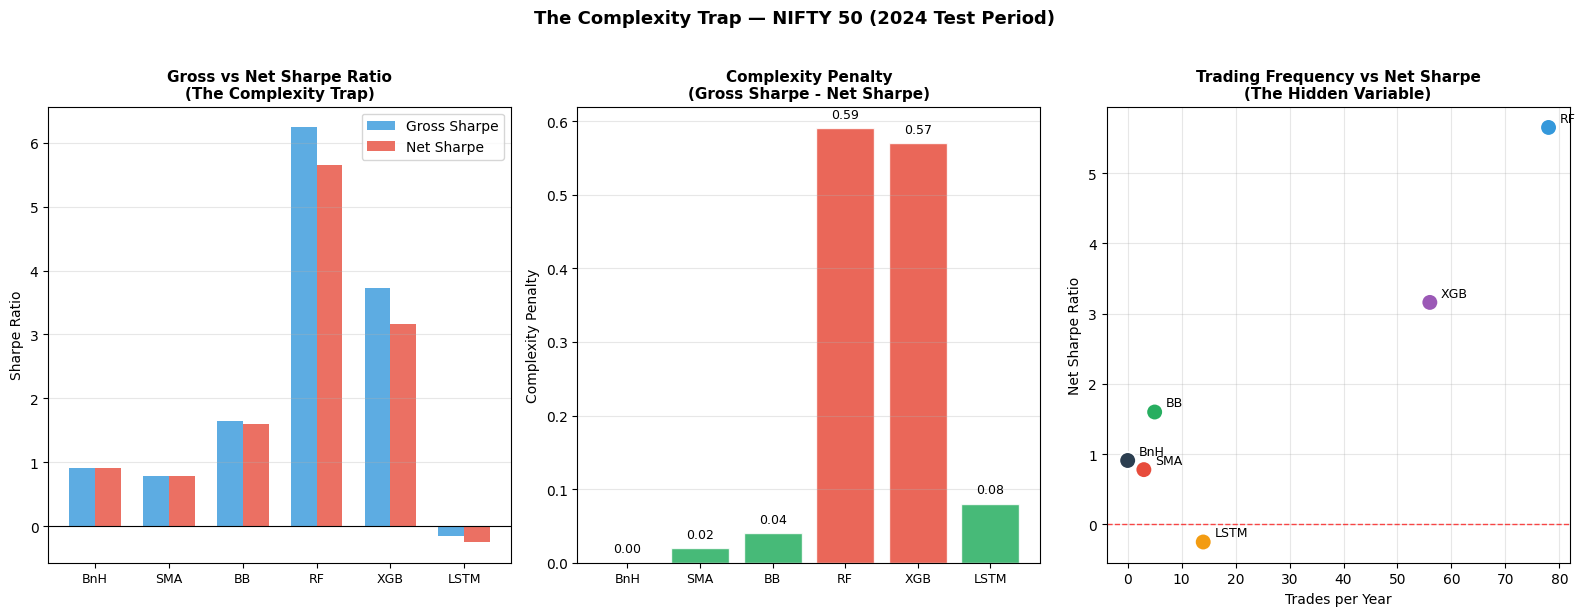

Chart 1 saved: complexity_trap_main.png


In [ ]:
# ============================================
# CHART 1: GROSS vs NET SHARPE (Complexity Penalty Visual)
# ============================================

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

strategy_names = results_df['Strategy'].tolist()
gross_sharpes = results_df['Gross Sharpe'].tolist()
net_sharpes = results_df['Net Sharpe'].tolist()
penalties = results_df['Complexity Penalty'].tolist()
trades_yr = results_df['Trades/Yr'].tolist()

colors = ['#2C3E50', '#E74C3C', '#27AE60', '#3498DB', '#9B59B6', '#F39C12']
x = np.arange(len(strategy_names))
width = 0.35

# Left chart: Gross vs Net Sharpe side by side
bars1 = axes[0].bar(x - width/2, gross_sharpes, width,
                     label='Gross Sharpe', color='#3498DB', alpha=0.8)
bars2 = axes[0].bar(x + width/2, net_sharpes, width,
                     label='Net Sharpe', color='#E74C3C', alpha=0.8)
axes[0].set_title('Gross vs Net Sharpe Ratio\n(The Complexity Trap)',
                   fontsize=11, fontweight='bold')
axes[0].set_ylabel('Sharpe Ratio')
axes[0].set_xticks(x)
axes[0].set_xticklabels(['BnH', 'SMA', 'BB', 'RF', 'XGB', 'LSTM'],
                         fontsize=9)
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].axhline(y=0, color='black', linewidth=0.8)

# Middle chart: Complexity Penalty by strategy
penalty_colors = ['#27AE60' if p < 0.1 else '#F39C12'
                  if p < 0.3 else '#E74C3C' for p in penalties]
bars3 = axes[1].bar(x, penalties, color=penalty_colors, alpha=0.85, edgecolor='white')
axes[1].set_title('Complexity Penalty\n(Gross Sharpe - Net Sharpe)',
                   fontsize=11, fontweight='bold')
axes[1].set_ylabel('Complexity Penalty')
axes[1].set_xticks(x)
axes[1].set_xticklabels(['BnH', 'SMA', 'BB', 'RF', 'XGB', 'LSTM'],
                         fontsize=9)
axes[1].grid(True, alpha=0.3, axis='y')
for bar, pen in zip(bars3, penalties):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.01,
                 f'{pen:.2f}', ha='center', va='bottom', fontsize=9)

# Right chart: Trading frequency vs Net Sharpe
axes[2].scatter(trades_yr, net_sharpes, c=colors,
                s=150, zorder=5, edgecolors='white', linewidth=1.5)
for i, name in enumerate(['BnH', 'SMA', 'BB', 'RF', 'XGB', 'LSTM']):
    axes[2].annotate(name,
                     (trades_yr[i], net_sharpes[i]),
                     textcoords="offset points",
                     xytext=(8, 4), fontsize=9)
axes[2].set_title('Trading Frequency vs Net Sharpe\n(The Hidden Variable)',
                   fontsize=11, fontweight='bold')
axes[2].set_xlabel('Trades per Year')
axes[2].set_ylabel('Net Sharpe Ratio')
axes[2].axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.7)
axes[2].grid(True, alpha=0.3)

plt.suptitle('The Complexity Trap — NIFTY 50 (2024 Test Period)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('complexity_trap_main.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 1 saved: complexity_trap_main.png")

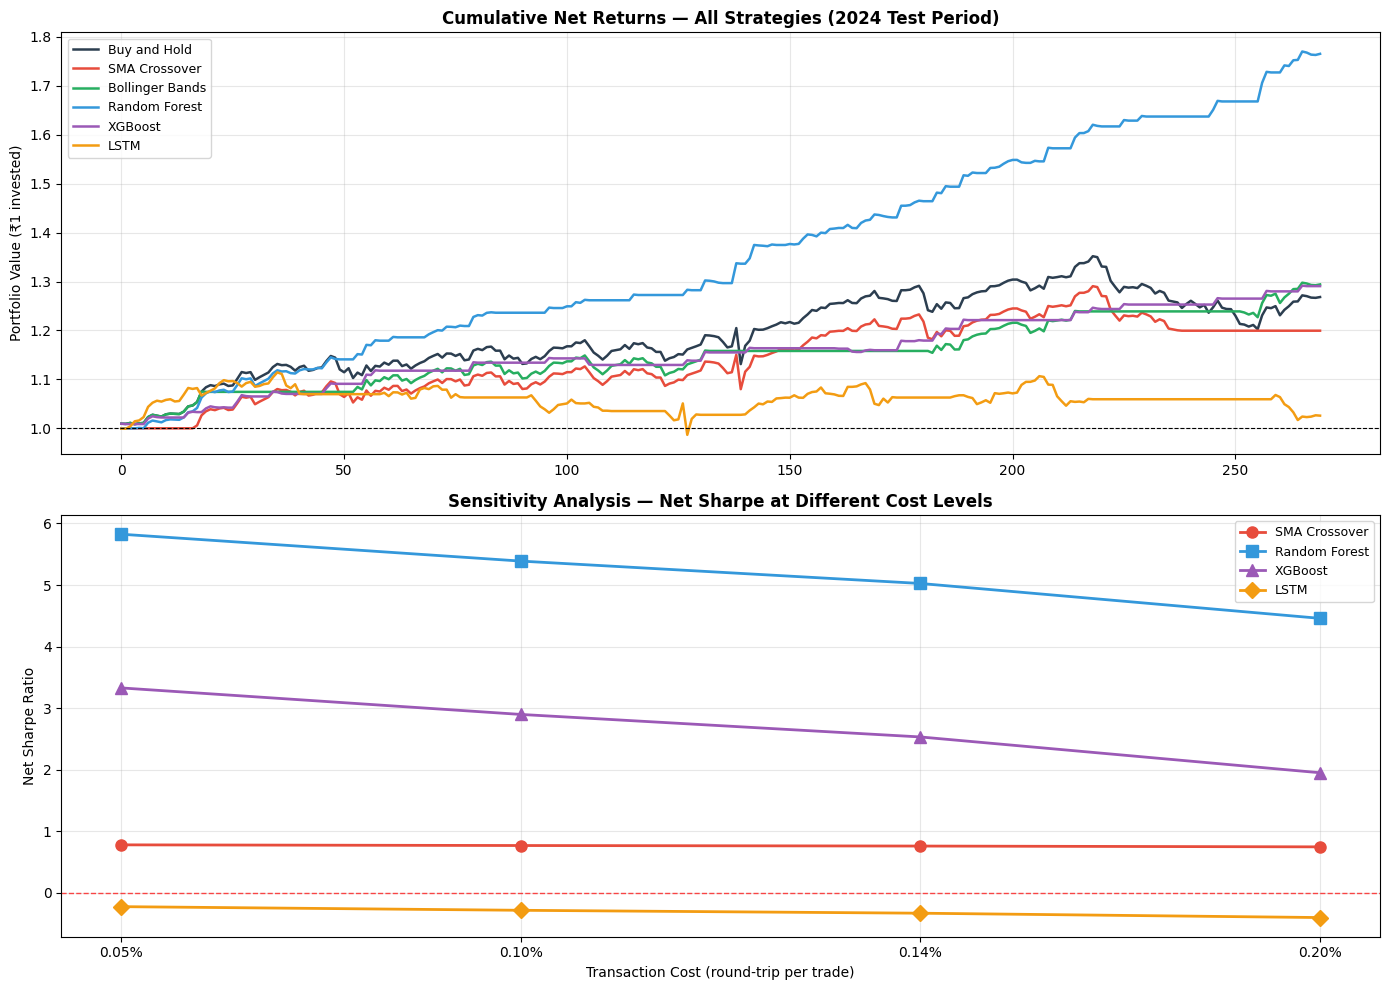

Chart 2 saved: cumulative_returns_sensitivity.png


In [ ]:
# ============================================
# CHART 2: CUMULATIVE RETURNS — ALL STRATEGIES
# ============================================

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Align all to same length for plotting
min_len = min(len(bnh_test_ret), len(sma_test_ret),
              len(bb_test_ret), len(rf_test_ret),
              len(xgb_test_ret), len(lstm_test_ret))

strategy_returns = {
    'Buy and Hold': pd.Series(bnh_net.values[:min_len]),
    'SMA Crossover': pd.Series(sma_net.values[:min_len]),
    'Bollinger Bands': pd.Series(bb_net.values[:min_len]),
    'Random Forest': pd.Series(rf_net.values[:min_len]),
    'XGBoost': pd.Series(xgb_net.values[:min_len]),
    'LSTM': pd.Series(lstm_net.values[:min_len]),
}

colors_map = {
    'Buy and Hold': '#2C3E50',
    'SMA Crossover': '#E74C3C',
    'Bollinger Bands': '#27AE60',
    'Random Forest': '#3498DB',
    'XGBoost': '#9B59B6',
    'LSTM': '#F39C12'
}

# Top: Net cumulative returns
for name, ret in strategy_returns.items():
    cumret = (1 + ret).cumprod()
    axes[0].plot(cumret.values, label=name,
                 color=colors_map[name], linewidth=1.8)

axes[0].set_title('Cumulative Net Returns — All Strategies (2024 Test Period)',
                   fontsize=12, fontweight='bold')
axes[0].set_ylabel('Portfolio Value (₹1 invested)')
axes[0].legend(fontsize=9, loc='upper left')
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=1, color='black', linestyle='--', linewidth=0.8)

## Bottom: Sensitivity analysis
cost_levels = [0.0005, 0.001, 0.0014, 0.002]
cost_labels = ['0.05%', '0.10%', '0.14%', '0.20%']
sma_sharpes_at_costs = []
rf_sharpes_at_costs = []
xgb_sharpes_at_costs = []
lstm_sharpes_at_costs = []

for cost in cost_levels:
    sma_n, _ = apply_costs(sma_test_ret, sma_test_signals, cost)
    rf_n, _ = apply_costs(rf_test_ret, rf_signals, cost)
    xgb_n, _ = apply_costs(xgb_test_ret, xgb_signals, cost)
    lstm_n, _ = apply_costs(lstm_test_ret, lstm_signals, cost)
    sma_sharpes_at_costs.append(sharpe(pd.Series(sma_n)))
    rf_sharpes_at_costs.append(sharpe(pd.Series(rf_n)))
    xgb_sharpes_at_costs.append(sharpe(pd.Series(xgb_n)))
    lstm_sharpes_at_costs.append(sharpe(pd.Series(lstm_n)))

x_costs = np.arange(len(cost_labels))
axes[1].plot(x_costs, sma_sharpes_at_costs, 'o-',
             color='#E74C3C', linewidth=2, label='SMA Crossover', markersize=8)
axes[1].plot(x_costs, rf_sharpes_at_costs, 's-',
             color='#3498DB', linewidth=2, label='Random Forest', markersize=8)
axes[1].plot(x_costs, xgb_sharpes_at_costs, '^-',
             color='#9B59B6', linewidth=2, label='XGBoost', markersize=8)
axes[1].plot(x_costs, lstm_sharpes_at_costs, 'D-',
             color='#F39C12', linewidth=2, label='LSTM', markersize=8)
axes[1].set_title('Sensitivity Analysis — Net Sharpe at Different Cost Levels',
                   fontsize=12, fontweight='bold')
axes[1].set_xlabel('Transaction Cost (round-trip per trade)')
axes[1].set_ylabel('Net Sharpe Ratio')
axes[1].set_xticks(x_costs)
axes[1].set_xticklabels(cost_labels)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.7)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('cumulative_returns_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 2 saved: cumulative_returns_sensitivity.png")

In [ ]:
print("=== SENSITIVITY ANALYSIS — NET SHARPE AT DIFFERENT COSTS ===")
print(f"{'Strategy':<18} {'0.05%':>8} {'0.10%':>8} {'0.14%':>8} {'0.20%':>8} {'Break-Even':>12}")
print("-" * 70)

for name, (gross_ret, _, signals) in strategies.items():
    sharpes_at_cost = []
    for cost in [0.0005, 0.001, 0.0014, 0.002]:
        net_r, _ = apply_costs(gross_ret, signals, cost)
        sharpes_at_cost.append(sharpe(pd.Series(net_r)))

    # Break-even cost: where net Sharpe hits zero
    # Approximate: mean return / n_trades gives break-even per trade
    gross_ret_s = pd.Series(gross_ret)
    n_tr = count_trades(signals)
    if n_tr > 0:
        be = (gross_ret_s.mean() * len(gross_ret_s) / n_tr) * 100
        be_str = f"{be:.3f}%"
    else:
        be_str = "N/A"

    print(f"{name:<18} {sharpes_at_cost[0]:>8.2f} {sharpes_at_cost[1]:>8.2f} "
          f"{sharpes_at_cost[2]:>8.2f} {sharpes_at_cost[3]:>8.2f} {be_str:>12}")

=== SENSITIVITY ANALYSIS — NET SHARPE AT DIFFERENT COSTS ===
Strategy              0.05%    0.10%    0.14%    0.20%   Break-Even
----------------------------------------------------------------------
Buy and Hold           0.91     0.91     0.91     0.91          N/A
SMA Crossover          0.78     0.77     0.76     0.75       5.977%
Bollinger Bands        1.61     1.58     1.55     1.52       3.742%
Random Forest          5.83     5.39     5.03     4.46       0.719%
XGBoost                3.33     2.90     2.53     1.95       0.490%
LSTM                  -0.22    -0.28    -0.33    -0.40       0.291%


In [ ]:
print("=" * 70)
print("  THE COMPLEXITY TRAP — COMPLETE RESULTS")
print("  NIFTY 50 | Test Period: Nov 2023 – Dec 2024 | 282 trading days")
print("=" * 70)
print(f"\n{'Strategy':<18} {'Gross':>7} {'Net':>7} {'Penalty%':>10} {'Break-Even':>12}")
print("-" * 60)

breakevens = {
    'Buy and Hold': 'N/A',
    'SMA Crossover': '5.977%',
    'Bollinger Bands': '3.742%',
    'Random Forest': '0.719%',
    'XGBoost': '0.490%',
    'LSTM': '0.291%'
}

for _, r in results_df.iterrows():
    print(f"{r['Strategy']:<18} {r['Gross Sharpe']:>7.2f} "
          f"{r['Net Sharpe']:>7.2f} {r['Penalty %']:>9.1f}% "
          f"{breakevens[r['Strategy']]:>12}")

print("\n")
print("KEY FINDING:")
print("SMA break-even cost: 5.977% — survives costs 12x higher than XGBoost")
print("XGBoost break-even: 0.490% — fails at 3.5x current Indian market costs")
print("LSTM break-even: 0.291% — already losing money at current cost levels")
print("\nComplexity Penalty increases monotonically with model sophistication:")
print("BnH: 0.0% → SMA: 1.9% → BB: 2.7% → RF: 9.4% → XGB: 15.3%")

  THE COMPLEXITY TRAP — COMPLETE RESULTS
  NIFTY 50 | Test Period: Nov 2023 – Dec 2024 | 282 trading days

Strategy             Gross     Net   Penalty%   Break-Even
------------------------------------------------------------
Buy and Hold          0.91    0.91       0.0%          N/A
SMA Crossover         0.79    0.78       1.9%       5.977%
Bollinger Bands       1.64    1.60       2.7%       3.742%
Random Forest         6.24    5.65       9.4%       0.719%
XGBoost               3.73    3.16      15.3%       0.490%
LSTM                 -0.16   -0.25     -50.9%       0.291%


KEY FINDING:
SMA break-even cost: 5.977% — survives costs 12x higher than XGBoost
XGBoost break-even: 0.490% — fails at 3.5x current Indian market costs
LSTM break-even: 0.291% — already losing money at current cost levels

Complexity Penalty increases monotonically with model sophistication:
BnH: 0.0% → SMA: 1.9% → BB: 2.7% → RF: 9.4% → XGB: 15.3%
